In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras import backend as K
from keras.layers import Input, Dense, Conv2D, Conv2DTranspose, Flatten, Lambda, Reshape
from keras.models import Model,load_model
from keras.losses import binary_crossentropy
from imutils import paths
from tensorflow.keras.utils import img_to_array
from sklearn.model_selection import train_test_split
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, Activation, BatchNormalization, MaxPooling2D, Dropout, GlobalAveragePooling1D
from keras.models import Sequential
from google.colab.patches import cv2_imshow
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report,confusion_matrix
import random
from PIL import Image

In [ ]:
# Read the kaggle API token to interact with your kaggle account
from google.colab import files
files.upload()
# Series of commands to set-up for download
!ls -lha kaggle.json
!pip install -q kaggle # installing the kaggle package
!mkdir -p ~/.kaggle # creating .kaggle folder where the key should be placed
!cp kaggle.json ~/.kaggle/ # move the key to the folder
!pwd # checking the present working directory
# giving rw access (if 401-nathorized)
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
-rw-r--r-- 1 root root 64 Jan 18 09:50 kaggle.json
/content


In [ ]:
# Download data command
!kaggle datasets download -d ckay16/accident-detection-from-cctv-footage

# # Unzip
!unzip /content/accident-detection-from-cctv-footage.zip -d .

Dataset URL: https://www.kaggle.com/datasets/ckay16/accident-detection-from-cctv-footage
License(s): ODbL-1.0
 99% 248M/249M [00:08<00:00, 35.9MB/s]
100% 249M/249M [00:08<00:00, 29.2MB/s]
Archive:  /content/accident-detection-from-cctv-footage.zip
  inflating: ./data/test/Accident/acc1 (7).jpg  
  inflating: ./data/test/Accident/test10_33.jpg  
  inflating: ./data/test/Accident/test10_56.jpg  
  inflating: ./data/test/Accident/test10_61.jpg  
  inflating: ./data/test/Accident/test12_13.jpg  
  inflating: ./data/test/Accident/test12_16.jpg  
  inflating: ./data/test/Accident/test13_22.jpg  
  inflating: ./data/test/Accident/test15_15.jpg  
  inflating: ./data/test/Accident/test18_22.jpg  
  inflating: ./data/test/Accident/test18_24.jpg  
  inflating: ./data/test/Accident/test19_26.jpg  
  inflating: ./data/test/Accident/test1_18.jpg  
  inflating: ./data/test/Accident/test1_20.jpg  
  inflating: ./data/test/Accident/test1_24.jpg  
  inflating: ./data/test/Accident/test1_26.jpg  
  infla

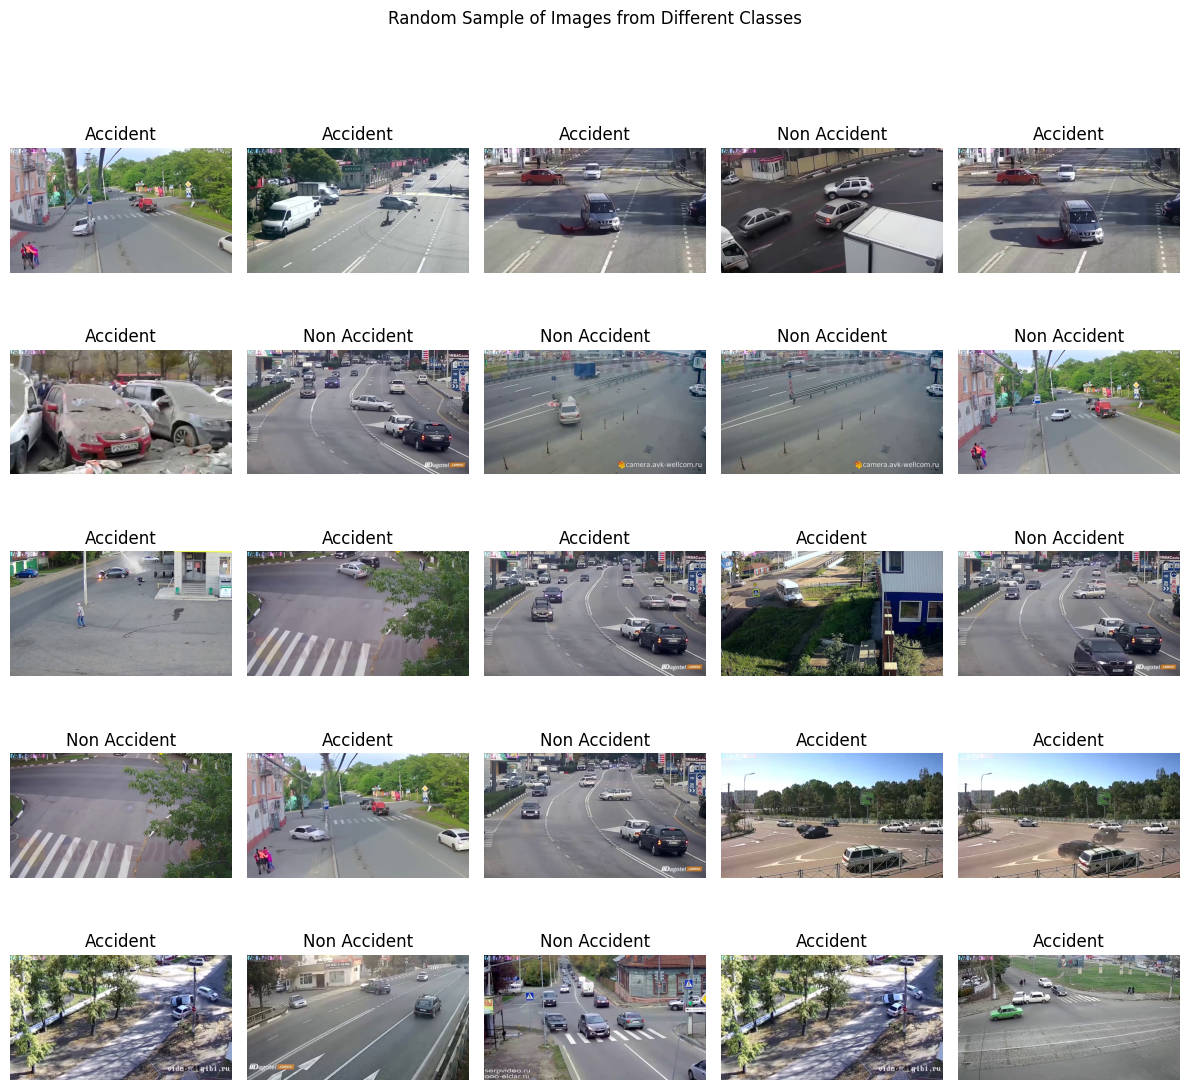

In [ ]:
# Get all image paths from the folder
imagePaths = list(paths.list_images("/content/data/train"))
# Function to display a grid of images
def display_images(image_paths, title, cols=5, num_images=25):  # Set cols and add num_images
    random.shuffle(image_paths)  # Shuffle the image paths randomly
    num_images = min(len(image_paths), num_images)  # Limit the number of images to display
    rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(12, 12))  # Adjust figure size to accommodate more rows
    plt.suptitle(title)

    for i, image_path in enumerate(image_paths[:num_images]):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(image_path)
        # Convert the image to RGB format
        img = img.convert('RGB')
        plt.imshow(img)
        plt.title(image_path.split(os.path.sep)[4])
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Display a random set of images in a 5x5 grid
display_images(imagePaths, title="Random Sample of Images from Different Classes", num_images=25)

In [ ]:
class SimpleDatasetLoader:
	def __init__(self, preprocessors=None):
		# store the image preprocessor
		self.preprocessors = preprocessors

		# if the preprocessors are None, initialize them as an
		# empty list
		if self.preprocessors is None:
			self.preprocessors = []

	def load(self, imagePaths, verbose=-1):
		# initialize the list of features and labels
		data = []
		labels = []

		# loop over the input images
		for (i, imagePath) in enumerate(imagePaths):
			# load the image and extract the class label assuming
			# that our path has the following format:
			# /path/to/dataset/{class}/{image}.jpg
			image = cv2.imread(imagePath)
			image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
			label = imagePath.split(os.path.sep)[-2]

			# check to see if our preprocessors are not None
			if self.preprocessors is not None:
				# loop over the preprocessors and apply each to
				# the image
				for p in self.preprocessors:
					image = p.preprocess(image)

			# treat our processed image as a "feature vector"
			# by updating the data list followed by the labels
			data.append(image)
			labels.append(label)

			# show an update every `verbose` images
			if verbose > 0 and i > 0 and (i + 1) % verbose == 0:
				print("[INFO] processed {}/{}".format(i + 1,
					len(imagePaths)))

		# return a tuple of the data and labels
		return (np.array(data), np.array(labels))

In [ ]:
class SimplePreprocessor:
	def __init__(self, width, height, inter=cv2.INTER_AREA):
		# store the target image width, height, and interpolation
		# method used when resizing
		self.width = width
		self.height = height
		self.inter = inter

	def preprocess(self, image):
		# resize the image to a fixed size, ignoring the aspect
		# ratio
		return cv2.resize(image, (self.width, self.height),
			interpolation=self.inter)

In [ ]:
class ImageToArrayPreprocessor:
	def __init__(self, dataFormat=None):
		# store the image data format
		self.dataFormat = dataFormat

	def preprocess(self, image):
		# apply the Keras utility function that correctly rearranges
		# the dimensions of the image
		return img_to_array(image, data_format=self.dataFormat)

In [ ]:
# initialize the image preprocessors
sp = SimplePreprocessor(128,128)
iap = ImageToArrayPreprocessor()

In [ ]:
# load train image paths
train_paths = list(paths.list_images("/content/data/train"))
val_paths = list(paths.list_images("/content/data/val"))
train_imagepaths = train_paths+val_paths
classNames = [pt.split(os.path.sep)[-2] for pt in train_imagepaths]
classNames = [str(x) for x in np.unique(classNames)]
classNames

['Accident', 'Non Accident']

# Visualize train image

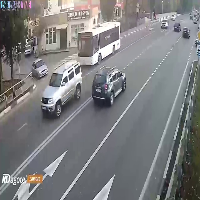

In [ ]:
img_read = cv2.imread(train_imagepaths[0])
img_resize = cv2.resize(img_read,(200,200))
cv2_imshow(img_resize)

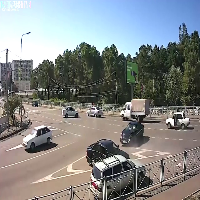

In [ ]:
img_read = cv2.imread(train_imagepaths[25])
img_resize = cv2.resize(img_read,(200,200))
cv2_imshow(img_resize)

In [ ]:
# load the trian dataset from disk then scale the raw pixel intensities to
# the range [0, 1]
sdl = SimpleDatasetLoader(preprocessors=[sp, iap])
(train_data, train_label) = sdl.load(train_imagepaths, verbose=500)
train_data = train_data.astype('float32') / 255.

[INFO] processed 500/889


In [ ]:
# load validaiton image paths
validation_imagePaths = list(paths.list_images("/content/data/test"))
classNames = [pt.split(os.path.sep)[-2] for pt in validation_imagePaths]
classNames = [str(x) for x in np.unique(classNames)]
classNames

['Accident', 'Non Accident']

# visualize validation image

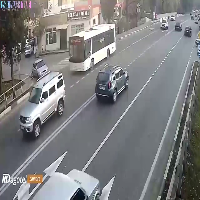

In [ ]:
img_read = cv2.imread(validation_imagePaths[50])
img_resize = cv2.resize(img_read,(200,200))
cv2_imshow(img_resize)

In [ ]:
# load the validation dataset from disk then scale the raw pixel intensities to
# the range [0, 1]
sdl = SimpleDatasetLoader(preprocessors=[sp, iap])
(validation_data,validation_label) = sdl.load(validation_imagePaths, verbose=10)
validation_data = validation_data.astype('float32') / 255.

[INFO] processed 10/100
[INFO] processed 20/100
[INFO] processed 30/100
[INFO] processed 40/100
[INFO] processed 50/100
[INFO] processed 60/100
[INFO] processed 70/100
[INFO] processed 80/100
[INFO] processed 90/100
[INFO] processed 100/100


original image shape (576, 720, 3)
preprocessed image shape (128, 128, 3)


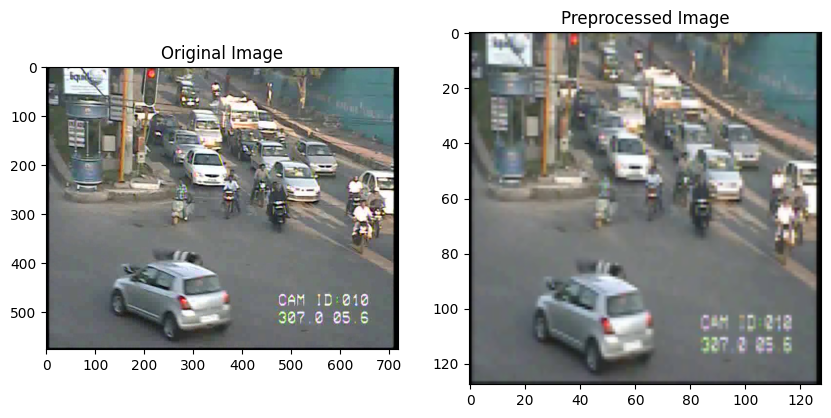

In [ ]:
# Define the image path
image_path = '/content/data/train/Accident/acc1 (2).jpg'

# Load the image using OpenCV
image = cv2.imread(image_path)
print("original image shape",image.shape)
# Initialize the SimplePreprocessor with desired width and height
preprocessor = SimplePreprocessor(128, 128)

# Preprocess the image (resize it)
preprocessed_image = preprocessor.preprocess(image)
print("preprocessed image shape",preprocessed_image.shape)
# Create a subplot to display images side by side
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')

# Preprocessed Image
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(preprocessed_image, cv2.COLOR_BGR2RGB))
plt.title('Preprocessed Image')

plt.show()

In [ ]:
# Apply Label encoder for train labels
le = LabelEncoder()
le.fit(train_label)
train_labels = le.transform(train_label)
train_labels = to_categorical(train_labels)

In [ ]:
# Apply Label encoder for validation  labels
le.fit(validation_label)
validation_labels = le.transform(validation_label)
validation_labels = to_categorical(validation_labels)

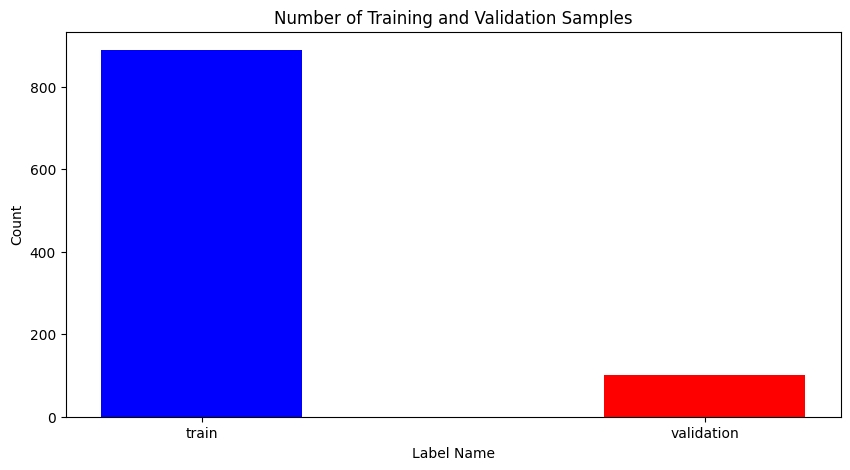

In [ ]:
train_count = train_labels.shape[0]
validation_count = validation_labels.shape[0]
counts = [train_count, validation_count]
fig = plt.figure(figsize=(10, 5))
label_name = ['train', 'validation']
plt.bar(label_name, counts, color=["blue", "red"], width=0.4)
plt.xlabel("Label Name")
plt.ylabel("Count")
plt.title("Number of Training and Validation Samples")
plt.show()


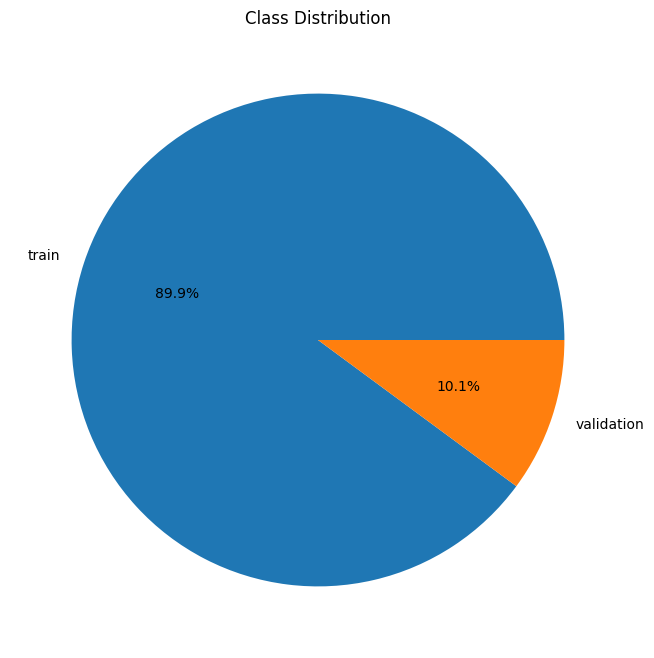

In [ ]:
import pandas as pd
train_count = train_labels.shape[0]
validation_count = validation_labels.shape[0]
label_counts = {'train': train_count, 'validation': validation_count}
df_counts = pd.DataFrame(label_counts.items(), columns=['Label', 'Count'])
plt.figure(figsize=(8, 8))
plt.pie(df_counts['Count'], labels=df_counts['Label'], autopct='%1.1f%%')
plt.title('Class Distribution')
plt.show()

# Training using Convolution neural network(CNN Model)

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import ModelCheckpoint
input_shape = (128,128,1)
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),activation='relu',padding = 'Same',input_shape=input_shape))
model.add(BatchNormalization())

model.add(Conv2D(32,kernel_size=(3, 3), activation='relu',padding = 'Same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu',padding = 'Same'))
model.add(BatchNormalization())

model.add(Conv2D(64, (3, 3), activation='relu',padding = 'Same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128,kernel_size=(3, 3), activation='relu',padding = 'Same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu',padding = 'Same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,345,314 (5.13 MB)

 Trainable params: 1,344,418 (5.13 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
if not os.path.exists("/content/drive/MyDrive/accident_detection"):
    os.mkdir("/content/drive/MyDrive/accident_detection")

In [ ]:
# Define the checkpoint callback
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/accident_detection/car_accident_model.weights.h5',  # Filepath to save the best weights
    monitor='val_accuracy',                     # Metric to monitor
    save_best_only=True,                    # Save only the best weights
    save_weights_only=True,                 # Save only weights, not the full model
    mode='max',                             # 'min' for validation loss
    verbose=1                               # Print messages when saving
)

# Define your optimizer using legacy Adam
optimizer = Adam(learning_rate=0.0001)

# Compile your model
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Assuming you have your train_data, train_labels, validation_data, and validation_labels defined
print("[INFO] training model...")
H = model.fit(train_data, train_labels, batch_size=16,
              validation_data=(validation_data, validation_labels), epochs=50, callbacks=[checkpoint])

[INFO] training model...
Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.5474 - loss: 1.1771
Epoch 1: val_accuracy improved from -inf to 0.53000, saving model to /content/drive/MyDrive/accident_detection/car_accident_model.weights.h5
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 273ms/step - accuracy: 0.5483 - loss: 1.1730 - val_accuracy: 0.5300 - val_loss: 0.7372
Epoch 2/50
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6436 - loss: 0.7010
Epoch 2: val_accuracy did not improve from 0.53000
56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.6443 - loss: 0.6994 - val_accuracy: 0.5300 - val_loss: 0.8033
Epoch 3/50
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6815 - loss: 0.5820
Epoch 3: val_accuracy did not improve from 0.53000
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6822 - loss: 0.5808 - val_accuracy: 0.5300 - val_loss: 0.9883
Epoch 4/50
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7775 - loss: 0.4717
Epoch 4: val_accuracy did not improve fr

# Validation

In [ ]:
# model load
model.load_weights("/content/drive/MyDrive/accident_detection/car_accident_model.weights.h5")
prediction = model.predict(validation_data)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 437ms/step


# classification report

In [ ]:
classNames = ['Accident', 'Not Accident']
print(classification_report(validation_labels.argmax(axis=1),
	prediction.argmax(axis=1), target_names=classNames))

              precision    recall  f1-score   support

    Accident       1.00      0.96      0.98        47
Not Accident       0.96      1.00      0.98        53

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



Confusion matrix

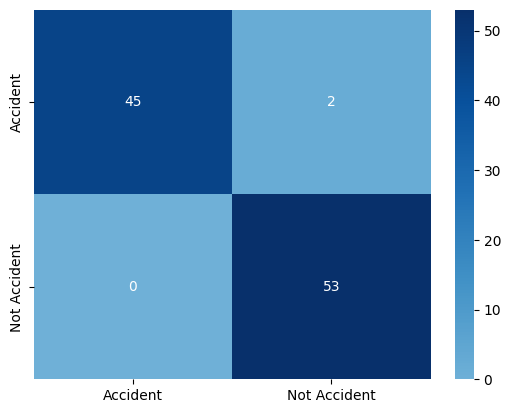

In [ ]:
import seaborn as sns
CM = confusion_matrix(validation_labels.argmax(axis=1),
	prediction.argmax(axis=1))
# drawing confusion matrix
sns.heatmap(CM, center = True , annot=True, fmt="d" ,cmap="Blues", xticklabels=classNames, yticklabels=classNames)
plt.show()

Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step
preicted class is: Not Accident


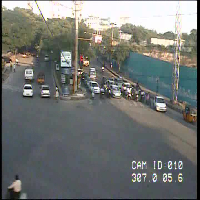

In [ ]:
image_path = "/content/data/train/Non Accident/5_17.jpg"
image = cv2.imread(image_path)
gray_img = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
sp = SimplePreprocessor(128,128)
data =  sp.preprocess(gray_img)
data = data.astype("float") / 255.0
data = np.expand_dims(data, axis=0)
data = np.expand_dims(data, axis=-1)
model.load_weights('/content/drive/MyDrive/accident_detection/car_accident_model.weights.h5')
preds = model.predict(data)
classNames = ['Accident', 'Not Accident']
print("preicted class is:", classNames[preds.argmax()])
image= cv2.resize(image, (200, 200))
cv2_imshow(image)